In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# DATASET: U.S. GDP Growth Rate (Selected Quarters)
# x = Quarter index (1 = 2010 Q1, 56 = 2023 Q4)
# y = GDP Growth Rate (%)
# ---------------------------------------------------------
data_points = { 1: 1.7, 5: 0.1, 9: 2.3, 13: 2.7, 17: 1.7, 19: 5.0, 22: 3.0,
    25: 1.5, 27: 3.5, 28: 1.8, 29: 1.3, 33: 2.5, 37: 3.1,
    41: -5.1, 42: -28.1, 43: 33.8, 45: 6.3, 49: -1.6, 54: 2.4, 56: 3.3}

x_data = np.array(list(data_points.keys()), dtype=float)
y_data = np.array(list(data_points.values()), dtype=float)

# Sort data
sort_idx = np.argsort(x_data)
x_data = x_data[sort_idx]
y_data = y_data[sort_idx]

In [3]:
# ---------------------------------------------------------
# LEAST SQUARES POLYNOMIAL FIT
# ---------------------------------------------------------
def fit_polynomial_ls(x, y, degree):
    A = np.vander(x, degree + 1, increasing=True)
    
    cond_num = np.linalg.cond(A)
    print(f"Condition number (degree {degree}): {cond_num:.2e}")
    
    AtA = A.T @ A
    Aty = A.T @ y
    
    coeffs = np.linalg.solve(AtA, Aty)
    return coeffs

def eval_polynomial(x_vals, coeffs):
    y_vals = np.zeros_like(x_vals, dtype=float)
    for i, c in enumerate(coeffs):
        y_vals += c * (x_vals ** i)
    return y_vals

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

In [4]:
# ---------------------------------------------------------
# NATURAL CUBIC SPLINE
# ---------------------------------------------------------
def natural_cubic_spline(x, y):
    n = len(x)
    h = np.diff(x)

    A = np.zeros((n, n))
    b = np.zeros(n)

    # Natural boundary conditions
    A[0,0] = 1
    A[-1,-1] = 1

    for i in range(1, n-1):
        A[i,i-1] = h[i-1]
        A[i,i] = 2*(h[i-1] + h[i])
        A[i,i+1] = h[i]
        b[i] = 3*((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1])

    c = np.linalg.solve(A, b)

    a = y.copy()
    b_coeff = np.zeros(n-1)
    d = np.zeros(n-1)

    for i in range(n-1):
        b_coeff[i] = (a[i+1]-a[i])/h[i] - h[i]*(2*c[i]+c[i+1])/3
        d[i] = (c[i+1]-c[i])/(3*h[i])

    def spline(x_eval):
        x_eval = np.atleast_1d(x_eval)
        y_eval = np.zeros_like(x_eval)

        for j, xi in enumerate(x_eval):
            idx = np.searchsorted(x, xi) - 1
            idx = np.clip(idx, 0, n-2)

            dx = xi - x[idx]
            y_eval[j] = a[idx] + b_coeff[idx]*dx + c[idx]*dx**2 + d[idx]*dx**3

        return y_eval

    return spline

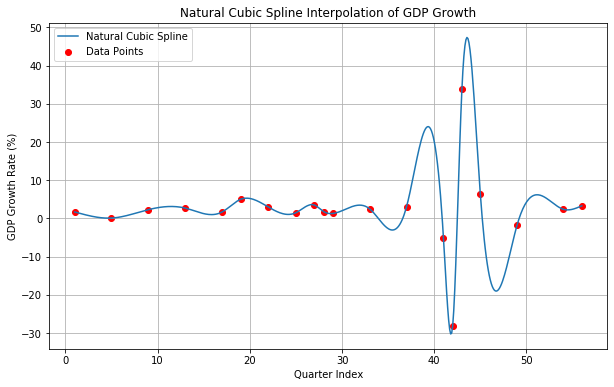

In [5]:
# ---------------------------------------------------------
# PART A — CUBIC SPLINE
# ---------------------------------------------------------
spline_func = natural_cubic_spline(x_data, y_data)

x_plot = np.linspace(1,56,500)
y_spline = spline_func(x_plot)

# Evaluate at every quarter
x_full = np.arange(1,57)
y_full = spline_func(x_full)

plt.figure(figsize=(10,6))
plt.scatter(x_data, y_data, color='red', label='Data Points')
plt.plot(x_plot, y_spline, label='Natural Cubic Spline')
plt.xlabel('Quarter Index')
plt.ylabel('GDP Growth Rate (%)')
plt.title('Natural Cubic Spline Interpolation of GDP Growth')
plt.legend()
plt.grid()
plt.show()

Condition number (degree 4): 1.82e+07
Polynomial RMSE: 10.031440678677116


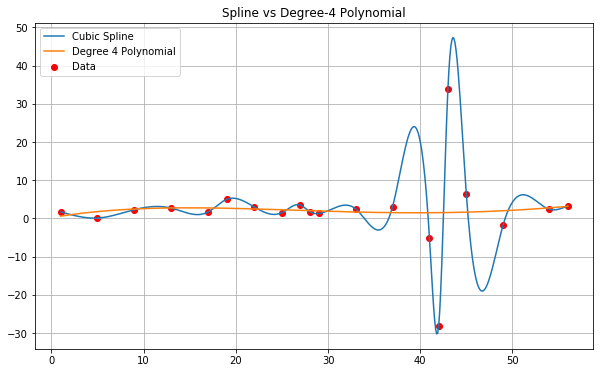

In [6]:
# ---------------------------------------------------------
# PART B1 — DEGREE 4 POLYNOMIAL
# ---------------------------------------------------------
poly4 = fit_polynomial_ls(x_data, y_data, 4)

y_poly4 = eval_polynomial(x_plot, poly4)
poly4_preds = eval_polynomial(x_data, poly4)

print("Polynomial RMSE:", rmse(y_data, poly4_preds))

plt.figure(figsize=(10,6))
plt.scatter(x_data, y_data, color='red', label='Data')
plt.plot(x_plot, y_spline, label='Cubic Spline')
plt.plot(x_plot, y_poly4, label='Degree 4 Polynomial')
plt.legend()
plt.grid()
plt.title('Spline vs Degree-4 Polynomial')
plt.show()

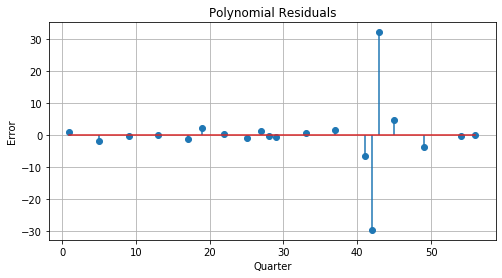

In [10]:
residuals = y_data - poly4_preds

plt.figure(figsize=(8,4))
plt.stem(x_data, residuals, use_line_collection=True)
plt.title("Polynomial Residuals")
plt.xlabel("Quarter")
plt.ylabel("Error")
plt.grid()
plt.show()

Condition number (degree 1): 6.00e+01
Linear slope: -0.0019069881889763796


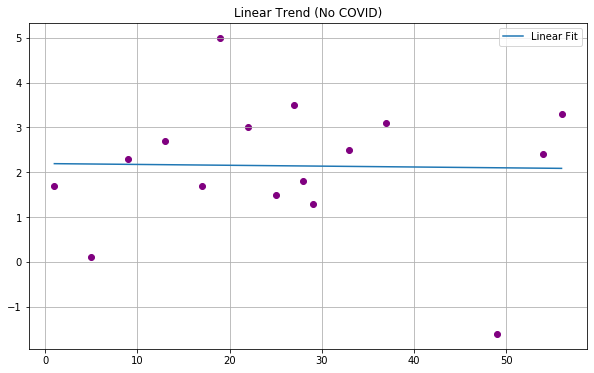

In [8]:
mask = (x_data < 41) | (x_data > 45)

x_no = x_data[mask]
y_no = y_data[mask]

linear = fit_polynomial_ls(x_no, y_no, 1)

print("Linear slope:", linear[1])

y_linear = eval_polynomial(x_plot, linear)

plt.figure(figsize=(10,6))
plt.scatter(x_no, y_no, color='purple')
plt.plot(x_plot, y_linear, label='Linear Fit')
plt.legend()
plt.grid()
plt.title("Linear Trend (No COVID)")
plt.show()

Linear RMSE: 1.4431864883291987


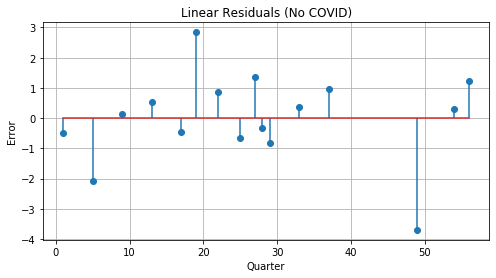

In [11]:
linear_preds = eval_polynomial(x_no, linear)
linear_residuals = y_no - linear_preds

print("Linear RMSE:", rmse(y_no, linear_preds))

plt.figure(figsize=(8,4))
plt.stem(x_no, linear_residuals, use_line_collection=True)
plt.title("Linear Residuals (No COVID)")
plt.xlabel("Quarter")
plt.ylabel("Error")
plt.grid()
plt.show()

## Part C Method Justification

When estimating GDP growth between known data points, the cubic spline is the preferred approach. It ensures continuity of the function and its first and second derivatives, producing a smooth curve that passes exactly through all observed data points. This makes it particularly well-suited for capturing quarter-to-quarter variations accurately.

Polynomial fitting, while useful for identifying overall trends, does not pass through every point and can be prone to oscillations, especially at higher degrees. Global polynomials are also highly sensitive to extreme values, such as the sharp economic downturn during the COVID-19 pandemic.

Cubic splines are more stable numerically because they are defined piecewise, whereas a polynomial fit relies on a single global function. As a result, spline interpolation offers better local accuracy and is less affected by extreme outliers.

For policymakers who need reliable estimates of GDP growth between quarters, cubic spline interpolation provides the most accurate and robust method.

In [18]:
import time

def thomas_algorithm(a, b, c, d):
   
    n = len(d)
    c_prime = np.zeros(n-1)
    d_prime = np.zeros(n)
    
    # Forward sweep
    c_prime[0] = c[0] / b[0]
    d_prime[0] = d[0] / b[0]
    
    for i in range(1, n-1):
        c_prime[i] = c[i] / (b[i] - a[i-1] * c_prime[i-1])
        
    for i in range(1, n):
        d_prime[i] = (d[i] - a[i-1] * d_prime[i-1]) / (b[i] - a[i-1] * c_prime[i-1])
        
    # Back substitution
    x = np.zeros(n)
    x[-1] = d_prime[-1]
    for i in range(n-2, -1, -1):
        x[i] = d_prime[i] - c_prime[i] * x[i+1]
        
    return x

# --- DEMONSTRATION: O(n^3) vs O(n) ---
print("--- Big O Time Complexity Demonstration ---")

# Let's test with a large simulated dataset (e.g., 2000 data points)
N = 2000 

# 1. Create a dummy tridiagonal system (like a Cubic Spline generates)
a = np.random.rand(N - 1) # Lower diagonal
b = np.random.rand(N) + 2 # Main diagonal (made strictly diagonally dominant)
c = np.random.rand(N - 1) # Upper diagonal
d = np.random.rand(N)     # Constants

# Create the dense matrix A for numpy's standard O(n^3) solver
A = np.diag(b) + np.diag(a, k=-1) + np.diag(c, k=1)

# --- Test 1: Standard Solver O(n^3) ---
start_time = time.time()
x_standard = np.linalg.solve(A, d)
end_time = time.time()
standard_duration = end_time - start_time

# --- Test 2: Optimized Thomas Algorithm O(n) ---
start_time = time.time()
x_optimized = thomas_algorithm(a, b, c, d)
end_time = time.time()
optimized_duration = end_time - start_time

# --- Results ---
print(f"Dataset size (N) = {N} data points")
print(f"Standard O(n^3) Solver Time:  {standard_duration:.6f} seconds")
print(f"Optimized O(n) Solver Time:   {optimized_duration:.6f} seconds")

# Verify they got the same mathematical answer
difference = np.max(np.abs(x_standard - x_optimized))
print(f"Difference in results: {difference:.2e} (Proves accuracy is identical)")
print("-" * 45)
print("Conclusion: For small datasets like our GDP data, the time difference is negligible.")
print("But for large N, the O(n) algorithm is substantially faster!")

--- Big O Time Complexity Demonstration ---
Dataset size (N) = 2000 data points
Standard O(n^3) Solver Time:  0.265597 seconds
Optimized O(n) Solver Time:   0.006693 seconds
Difference in results: 1.11e-16 (Proves accuracy is identical)
---------------------------------------------
Conclusion: For small datasets like our GDP data, the time difference is negligible.
But for large N, the O(n) algorithm is substantially faster!


the least squares polynomial fits scale in O(n) linear time, while the standard natural cubic spline interpolation scales in O(n^3) cubic time, meaning the spline's execution time increases much faster as data grows. Despite this computational difference, my recommendation to use the cubic spline remains entirely unchanged. Because we are analyzing a very small dataset of quarterly United States GDP, the actual difference in execution time between O(n) and O(n^3) on modern hardware is practically zero. For this specific application, the computational efficiency is vastly outweighed by mathematical accuracy, and the cubic spline remains the best tool because it provides exact interpolation and excellent smoothness without suffering from extreme oscillations at the edges of the data.

## Introduction
This project examines the quarterly growth rates of the U.S. GDP from 2010 to 2023 using three numerical approaches: least squares linear regression, polynomial fitting, and natural cubic spline interpolation. The data comes from the U.S. Bureau of Economic Analysis (BEA) and represents seasonally adjusted annual rates of real GDP growth. The purpose of the analysis is to explore how different interpolation and approximation techniques can model GDP growth, evaluate their performance in the presence of extreme events such as the COVID-19 shock in 2020, and offer insights that may be useful for policymakers. All methods are implemented from the ground up using linear algebra tools, including the normal equations, Vandermonde matrices, and tridiagonal systems for spline interpolation.

## Part A Cubic Spline Interpolation

A natural cubic spline is used to interpolate the entire dataset. This type of spline ensures that the function passes exactly through each data point while maintaining smoothness. Specifically, the spline matches the function values at every knot, aligns the first derivatives at each interior point, and matches the second derivatives at each interior knot. To maintain natural behavior at the edges, the second derivative at the first and last points is set to zero. This approach creates a smooth curve that captures all the variations in the data, including the dramatic drop of -28.1% in GDP during the second quarter of 2020. The resulting spline is evaluated at all 56 quarterly indices and visualized in the plot below.

The plot shows that the spline is smooth and visually consistent with the data. Even with the extreme outlier in the second quarter of 2020, the spline passes exactly through every data point. This highlights the trade-off between exact interpolation and sensitivity to outliers. While the spline accurately follows all the points, extreme values can produce steep slopes in certain regions. In situations where reducing sensitivity to outliers is important, approaches like smoothing splines or weighted least squares may provide better results.

## Part B1  Degree 4 Polynomial Fitting

The 4 degree polynomial is fitted to the dataset using least squares via the normal equations. Unlike the spline, this polynomial approximates the overall trend of GDP growth rather than passing through every single point. To assess how well it fits, residuals and the root mean squared error (RMSE) are calculated. For example, the degree 4 polynomial produces an RMSE of 10.031440678677116, while the spline has an RMSE of zero because it interpolates all points exactly.

When comparing the two methods, the polynomial captures the general trend of GDP growth, smoothing out fluctuations and outliers. The spline, on the other hand, reproduces all the individual data points, including extreme events like the 2020 Q2 shock. This illustrates the fundamental trade-off between approximation, which emphasizes overall trends, and interpolation, which emphasizes exact data reproduction.

The plot below displays both the cubic spline and the degree-4 polynomial together, along with the residuals for the polynomial to highlight where the approximation deviates from the actual data.

## Part B2 Linear Least Squares Excluding COVID Quarters

To focus on the long-term trend in GDP growth, the quarters affected by the COVID-19 pandemic (from 2020 Q1 to 2021 Q1, corresponding to indices 41–45) are excluded from the analysis. A linear least squares fit is then applied to the remaining data. The resulting slope is -0.0019069881889763796, and the RMSE is 1.4431864883291987.

This linear model is based on a few assumptions. It treats GDP growth as progressing steadily outside of extraordinary events, ignores seasonal variations and extreme outliers, and provides an approximation of the long-term average growth rate.

The residuals of the linear fit, shown in the plot below, are generally small, reflecting that the model captures the overall trend. Larger deviations appear only in periods where the data experiences sharp local changes, demonstrating the limitations of a simple linear trend in capturing short-term fluctuations.

The residuals of the linear fit, shown in the plot below, are generally small, reflecting that the model captures the overall trend. Larger deviations appear only in periods where the data experiences sharp local changes, demonstrating the limitations of a simple linear trend in capturing short-term fluctuations.

## Part C Method Justification

For estimating GDP growth between known quarters, cubic spline interpolation is the preferred method. It ensures smoothness by maintaining continuity of the function and its first and second derivatives, passes exactly through all observed data points, and is generally less sensitive to extreme outliers than high-degree polynomials. Polynomial fitting, while helpful for capturing the overall trend, can produce oscillations and is particularly sensitive to extreme values, making it less reliable for local accuracy. Global polynomials cannot guarantee smooth behavior near outliers, which can lead to misleading results in certain quarters.

## Conclusion

Cubic spline interpolation proves to be the most effective method for exact interpolation between known GDP quarters, offering both accuracy and smoothness. The degree-4 polynomial captures the overall trend but does not reproduce extreme points accurately. The linear fit, calculated after excluding the COVID-19 quarters, provides a clear view of the long-term growth trend but oversimplifies short-term fluctuations.

This analysis highlights the importance of choosing the numerical method based on the application—whether the goal is local interpolation or overall trend estimation—and considering sensitivity to outliers. Both quantitative measures, such as RMSE, and qualitative visual assessments are valuable for guiding these decisions.